### Model Selection
### Used Car Price Prediction — ML Training Pipeline
**Justin King Bais | University of Mindanao**

This notebook covers:
- Loading preprocessed data from data_preprocessing.ipynb
- Training Linear Regression (Human-Selected)
- Training Gradient Boosting Regressor (AI-Recommended)
- Evaluating both models using MAE, MSE, R²
- Comparing results and selecting the best model
- Saving the selected model artifact

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os

from google.colab import files
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'serif'

print("Libraries loaded.")

Libraries loaded.


### 1. Load Preprocessed Data

In [4]:
X_train        = np.load('X_train.npy')
X_test         = np.load('X_test.npy')
y_train        = np.load('y_train.npy')
y_test         = np.load('y_test.npy')
feature_cols   = joblib.load('feature_columns.pkl')
scaler         = joblib.load('scaler.pkl')
label_encoders = joblib.load('label_encoders.pkl')

print("All files loaded successfully.")
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"feature_cols  : {feature_cols}")

All files loaded successfully.
X_train shape : (5920, 8)
X_test shape  : (1480, 8)
feature_cols  : ['kms_run', 'fuel_type', 'city', 'times_viewed', 'body_type', 'transmission', 'car_age', 'kms_per_year']


### 2. Model 1 — Linear Regression (Human-Selected)

**Justification:**
- Most foundational regression algorithm for continuous target prediction
- Serves as an interpretable baseline
- Coefficient-based output allows direct interpretation of feature contributions
- Known limitation: assumes linear relationships which may not hold for used car pricing

In [6]:
# Train Linear Regression
# Human-selected as the baseline model
# Trained using Ordinary Least Squares minimizing Residual Sum of Squares

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred  = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2  = r2_score(y_test, lr_pred)

print("=== Model 1: Linear Regression ===")
print(f"MAE : INR {lr_mae:,.2f}")
print(f"MSE : {lr_mse:,.2f}")
print(f"R2  : {lr_r2:.4f}")
print(f"\nThe model explains {lr_r2*100:.1f}% of sale price variance.")
print(f"Average prediction error: INR {lr_mae:,.0f}")

=== Model 1: Linear Regression ===
MAE : INR 125,327.48
MSE : 36,924,753,772.86
R2  : 0.4696

The model explains 47.0% of sale price variance.
Average prediction error: INR 125,327


### 3. Model 2 — Gradient Boosting Regressor (AI-Recommended)

**AI Consultation (Claude by Anthropic):**
Gradient Boosting was recommended because:
- Handles non-linear relationships between features and price
- Robust to mixed numerical and categorical feature types after encoding
- Sequential error-correction mechanism outperforms linear models on structured tabular data
- Natively provides feature importance scores for interpretability

**Update rule:** Fm(x) = Fm-1(x) + ν × hm(x)
where ν is the learning rate and hm(x) is the new weak learner
fitted to pseudo-residuals of the previous model.

In [7]:
# Train Gradient Boosting Regressor
# AI-recommended model — configuration from train_model.py

gb_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_mse = mean_squared_error(y_test, gb_pred)
gb_r2  = r2_score(y_test, gb_pred)

print("=== Model 2: Gradient Boosting Regressor ===")
print(f"MAE : INR {gb_mae:,.2f}")
print(f"MSE : {gb_mse:,.2f}")
print(f"R2  : {gb_r2:.4f}")
print(f"\nThe model explains {gb_r2*100:.1f}% of sale price variance.")
print(f"Average prediction error: INR {gb_mae:,.0f}")

=== Model 2: Gradient Boosting Regressor ===
MAE : INR 90,663.12
MSE : 19,267,575,788.25
R2  : 0.7232

The model explains 72.3% of sale price variance.
Average prediction error: INR 90,663


### 4. Model Comparison and Initial Evaluation

In [8]:
# Side by side comparison
print("=" * 58)
print(f"{'Metric':<15} {'Linear Regression':>20} {'Gradient Boosting':>20}")
print("=" * 58)
print(f"{'MAE (INR)':<15} {lr_mae:>20,.2f} {gb_mae:>20,.2f}")
print(f"{'MSE':<15} {lr_mse:>20,.2f} {gb_mse:>20,.2f}")
print(f"{'R2 Score':<15} {lr_r2:>20.4f} {gb_r2:>20.4f}")
print("=" * 58)
print(f"\nR2 improvement (GB over LR) : +{gb_r2 - lr_r2:.4f}")
print(f"MAE improvement (GB over LR): INR {lr_mae - gb_mae:,.0f} less error")

Metric             Linear Regression    Gradient Boosting
MAE (INR)                 125,327.48            90,663.12
MSE                36,924,753,772.86    19,267,575,788.25
R2 Score                      0.4696               0.7232

R2 improvement (GB over LR) : +0.2536
MAE improvement (GB over LR): INR 34,664 less error


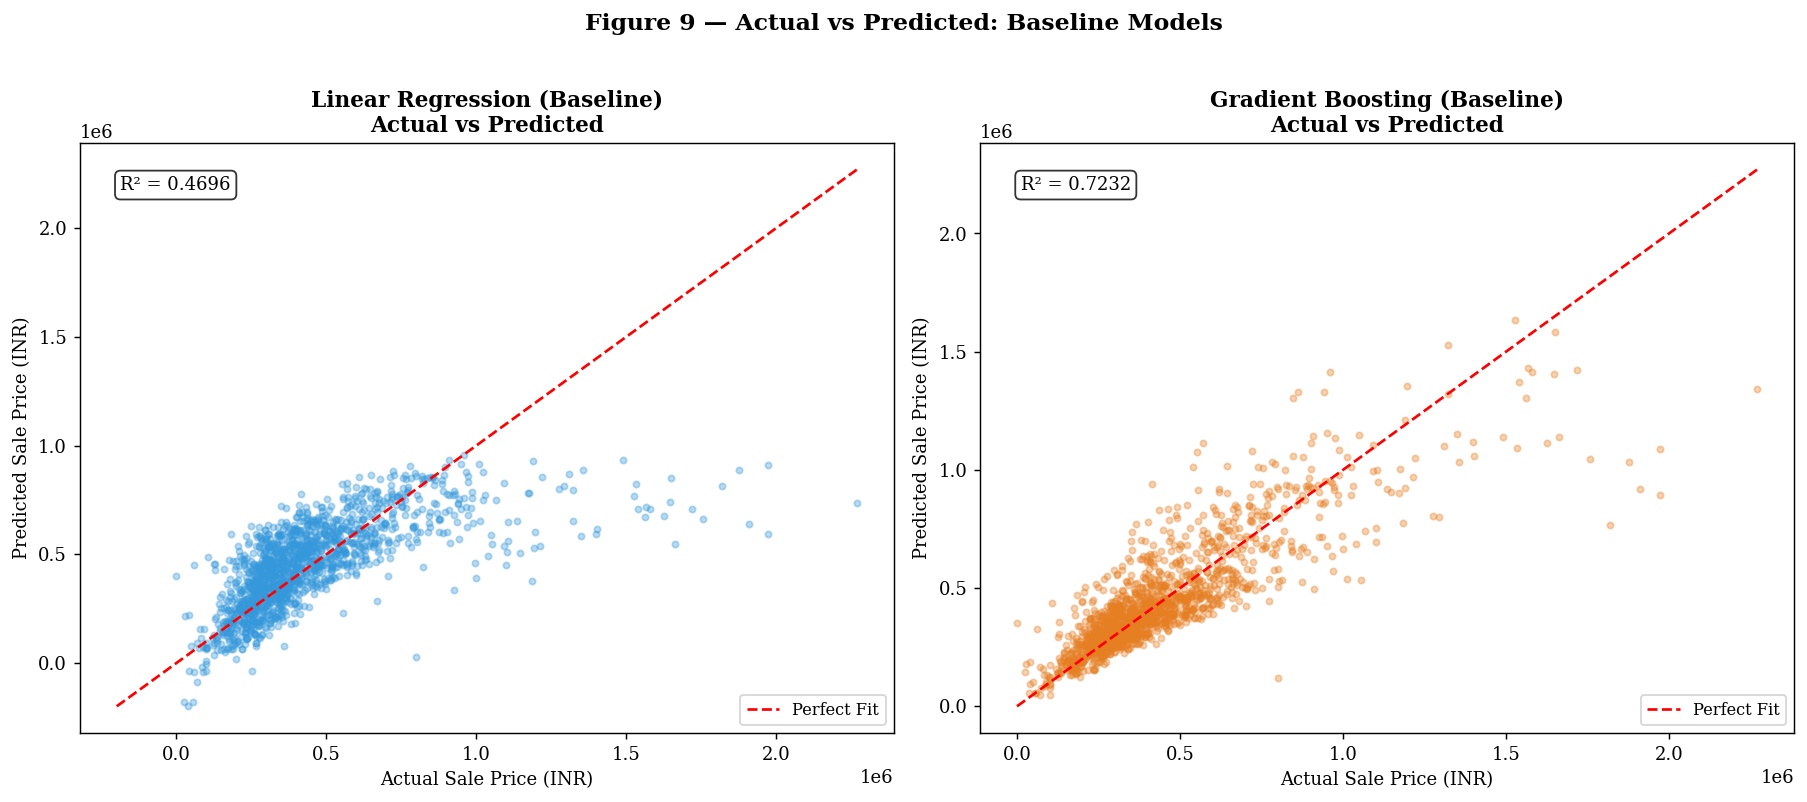

In [9]:
# Figure 9 — Actual vs Predicted: Both Models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pairs = [
    ('Linear Regression (Baseline)', lr_pred, '#3498db', lr_r2),
    ('Gradient Boosting (Baseline)', gb_pred, '#e67e22', gb_r2),
]

for ax, (name, pred, color, r2) in zip(axes, pairs):
    ax.scatter(y_test, pred, alpha=0.35, color=color, s=12)
    mn = min(y_test.min(), pred.min())
    mx = max(y_test.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect Fit')
    ax.set_title(f'{name}\nActual vs Predicted', fontweight='bold')
    ax.set_xlabel('Actual Sale Price (INR)')
    ax.set_ylabel('Predicted Sale Price (INR)')
    ax.text(0.05, 0.92, f'R² = {r2:.4f}',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.legend(fontsize=9)

fig.suptitle('Figure 9 — Actual vs Predicted: Baseline Models',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig9_actual_vs_predicted_baseline.png', bbox_inches='tight')
plt.show()

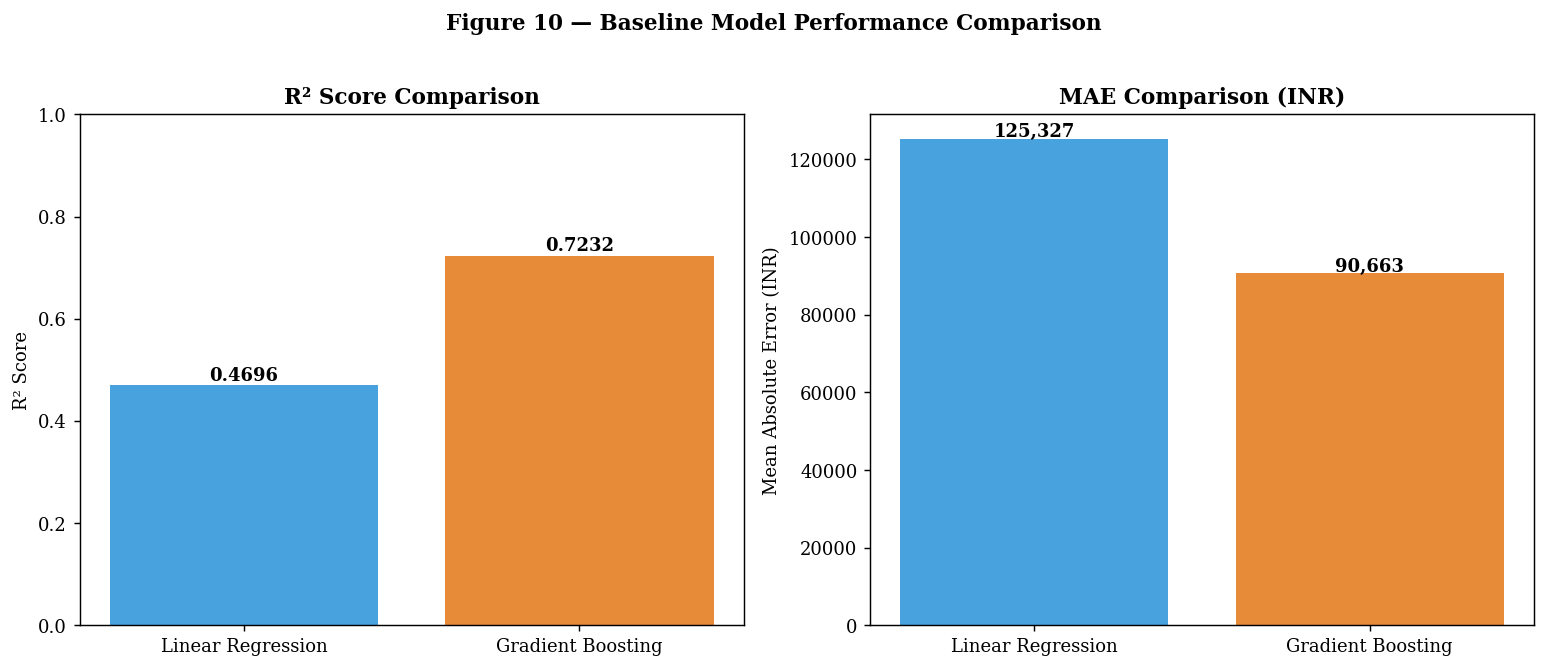

In [10]:
# Figure 10 — Model comparison bar charts
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models  = ['Linear Regression', 'Gradient Boosting']
r2_vals = [lr_r2, gb_r2]
mae_vals= [lr_mae, gb_mae]
colors  = ['#3498db', '#e67e22']

bars = axes[0].bar(models, r2_vals, color=colors, edgecolor='none', alpha=0.9)
axes[0].set_title('R² Score Comparison', fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.0)
for bar, val in zip(bars, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 0.01, f'{val:.4f}',
                 ha='center', fontsize=10, fontweight='bold')

bars2 = axes[1].bar(models, mae_vals, color=colors, edgecolor='none', alpha=0.9)
axes[1].set_title('MAE Comparison (INR)', fontweight='bold')
axes[1].set_ylabel('Mean Absolute Error (INR)')
for bar, val in zip(bars2, mae_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 500, f'{val:,.0f}',
                 ha='center', fontsize=10, fontweight='bold')

fig.suptitle('Figure 10 — Baseline Model Performance Comparison',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig10_model_comparison_baseline.png', bbox_inches='tight')
plt.show()

=== Feature Importance: Gradient Boosting ===
  1. body_type         : 0.4237 (42.4%)
  2. car_age           : 0.3117 (31.2%)
  3. fuel_type         : 0.0911 (9.1%)
  4. transmission      : 0.0645 (6.5%)
  5. kms_run           : 0.0424 (4.2%)
  6. kms_per_year      : 0.0257 (2.6%)
  7. times_viewed      : 0.0211 (2.1%)
  8. city              : 0.0198 (2.0%)


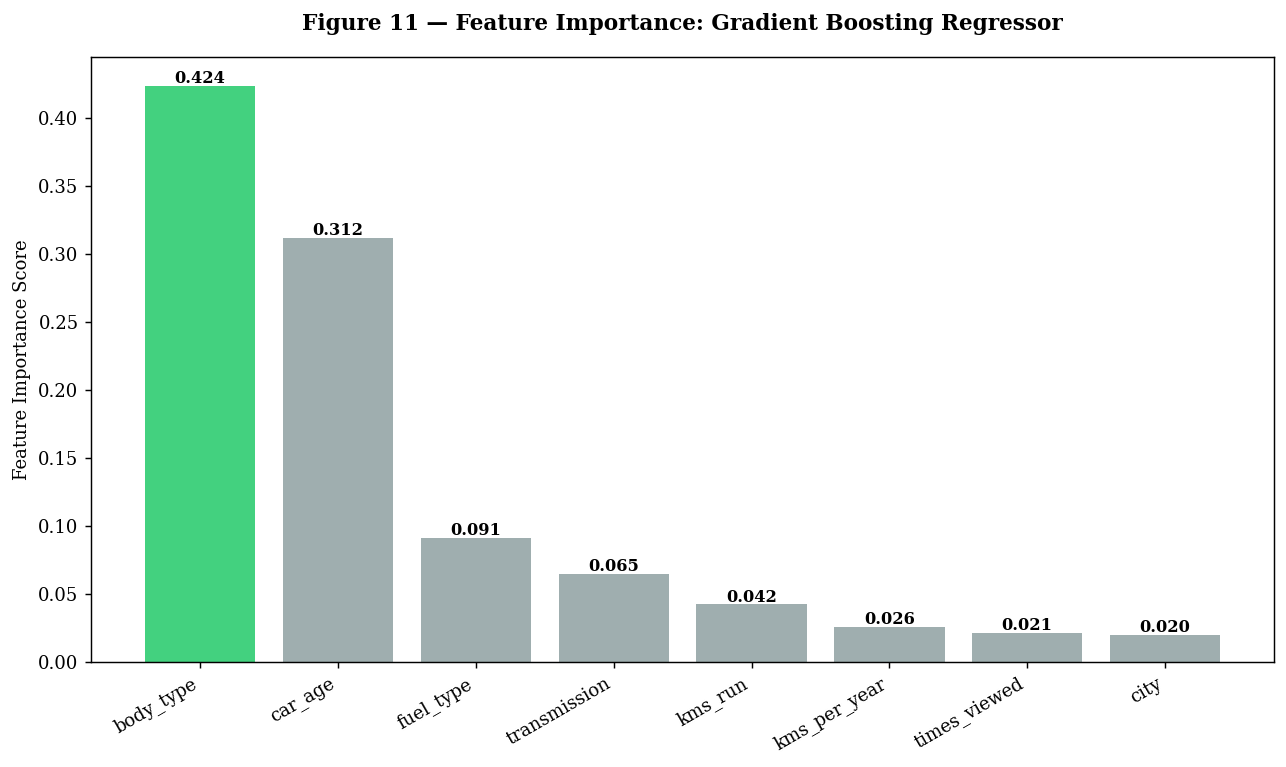

In [11]:
# Figure 11 — Feature Importance (Gradient Boosting)
importances = gb_model.feature_importances_
indices     = np.argsort(importances)[::-1]

print("=== Feature Importance: Gradient Boosting ===")
for rank, idx in enumerate(indices):
    print(f"  {rank+1}. {feature_cols[idx]:<18}: {importances[idx]:.4f} "
          f"({importances[idx]*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = ['#2ecc71' if i == 0 else '#95a5a6' for i in range(len(feature_cols))]
bars = ax.bar(range(len(feature_cols)),
              [importances[i] for i in indices],
              color=colors_imp, edgecolor='none', alpha=0.9)
ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels([feature_cols[i] for i in indices], rotation=30, ha='right')
ax.set_ylabel('Feature Importance Score')
ax.set_title('Figure 11 — Feature Importance: Gradient Boosting Regressor',
             fontsize=12, fontweight='bold', pad=15)
for bar, idx in zip(bars, indices):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{importances[idx]:.3f}',
            ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('fig11_feature_importance.png', bbox_inches='tight')
plt.show()

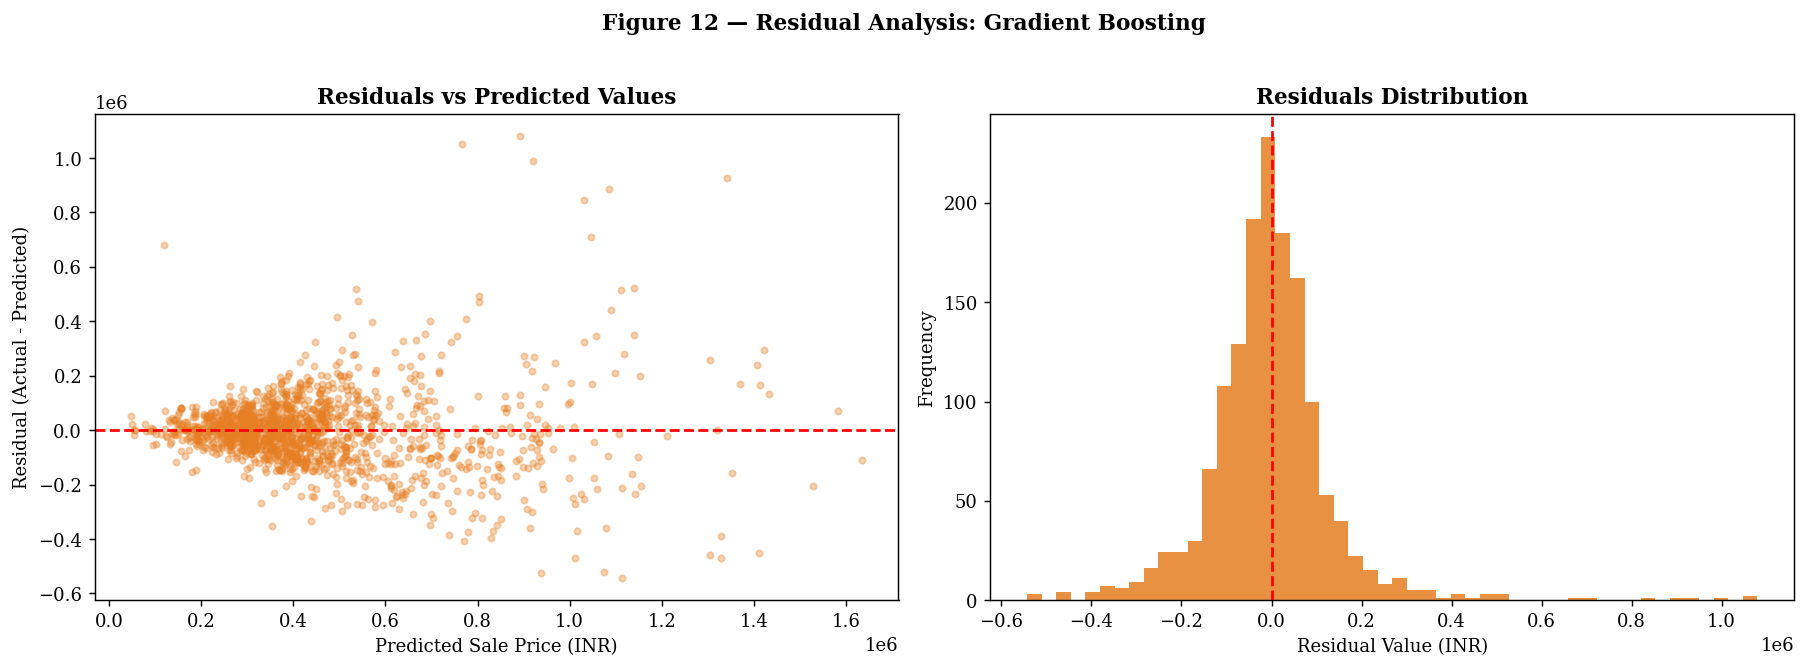

Mean residual   : -5,310 (should be close to 0)
Std of residuals: 138,706


In [12]:
# Figure 12 — Residual analysis (Gradient Boosting)
residuals = y_test - gb_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(gb_pred, residuals, alpha=0.35, color='#e67e22', s=12)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Sale Price (INR)')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residuals vs Predicted Values', fontweight='bold')

axes[1].hist(residuals, bins=50, color='#e67e22', edgecolor='none', alpha=0.85)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual Value (INR)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residuals Distribution', fontweight='bold')

fig.suptitle('Figure 12 — Residual Analysis: Gradient Boosting',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig12_residuals_baseline.png', bbox_inches='tight')
plt.show()

print(f"Mean residual   : {residuals.mean():,.0f} (should be close to 0)")
print(f"Std of residuals: {residuals.std():,.0f}")

In [13]:
# Save selected model and feature info

os.makedirs('../models', exist_ok=True)
joblib.dump(gb_model, '../models/model.pkl')

feature_info = {
    "selected_model": "GradientBoostingRegressor",
    "baseline_lr_r2" : round(lr_r2, 4),
    "baseline_lr_mae": round(lr_mae, 2),
    "baseline_lr_mse": round(lr_mse, 2),
    "baseline_gb_r2" : round(gb_r2, 4),
    "baseline_gb_mae": round(gb_mae, 2),
    "baseline_gb_mse": round(gb_mse, 2),
    "features"       : feature_cols,
    "n_estimators"   : 500,
    "learning_rate"  : 0.03,
    "max_depth"      : 3,
    "train_samples"  : int(X_train.shape[0]),
    "test_samples"   : int(X_test.shape[0])
}

with open('../models/feature_info.json', 'w') as f:
    json.dump(feature_info, f, indent=2)

print("Saved: ../models/model.pkl")
print("Saved: ../models/feature_info.json")
print(f"\nSelected model: Gradient Boosting (R2={gb_r2:.4f})")

Saved: ../models/model.pkl
Saved: ../models/feature_info.json

Selected model: Gradient Boosting (R2=0.7232)


### Model Selection Summary

**Selected Model: Gradient Boosting Regressor**

Gradient Boosting outperforms Linear Regression across all three metrics.
R² improved from 0.4696 to 0.7232 — confirming that used car pricing
is substantially non-linear and requires an ensemble approach.

→ Proceed to `hyperparameter_tuning.ipynb` for refinement.